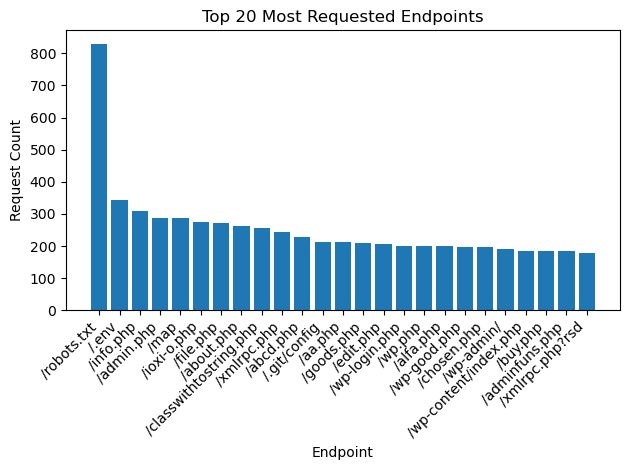

In [14]:
import requests
import re
import matplotlib.pyplot as plt

url = "https://example.com/logs"
response = requests.get(url)

endpoints = {}

lines = response.text.splitlines()

for i, line in enumerate(lines):

    if i == 0:
        continue

    match = re.search(r"Endpoint\s+(\S+)", line)
    if not match:
        continue

    endpoint = match.group(1)

    if endpoint == "/":
        continue 
    if endpoint == "/favicon.ico":
        continue
    if endpoint == "/memes":
        continue
    if endpoint == "/logs":
        continue
    
    endpoints[endpoint] = endpoints.get(endpoint, 0) + 1

#print(endpoints)



# sort and take top 20
top_20 = sorted(endpoints.items(), key=lambda x: x[1], reverse=True)[:25]

labels = [k for k, v in top_20]
values = [v for k, v in top_20]

plt.figure()
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Endpoint")
plt.ylabel("Request Count")
plt.title("Top 20 Most Requested Endpoints")
plt.tight_layout()
plt.show()